In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [ ]:
cleaned_data= pd.read_csv('/content/drive/MyDrive/raw_wide_cleaned_cities.csv')
cleaned_data.head()

,Unnamed: 0,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name
0,0,2016-01-23 03:15:00+00:00,IN,Delhi,Income Tax Office,28.623500,77.249400,NaN,NaN,NaN,NaN,28.0,90.0,2,CPCB
1,1,2016-02-09 20:00:00+00:00,GB,Haringey,Haringey - Haringey Town Hall,51.587936,-0.105438,10.0,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network
2,2,2016-02-09 20:00:00+00:00,GB,London,Haringey Roadside,51.507446,-0.127765,10.0,NaN,NaN,NaN,NaN,NaN,1,DEFRA
3,3,2016-02-16 18:00:00+00:00,CL,Llayllay,Los Vientos,-40.801776,-73.219064,NaN,57.87,NaN,432.562,NaN,740.7,4,Chile - SINCA
4,4,2016-02-19 01:00:00+00:00,TH,Loei,"Na An, Mueang",17.315856,101.463828,NaN,NaN,NaN,NaN,NaN,801.5,1,Thailand


In [ ]:
# Drop the accidental index column
if 'Unnamed: 0' in cleaned_data.columns:
    cleaned_data = cleaned_data.drop(columns=['Unnamed: 0'])
cleaned_data.head(2)

,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name
0,2016-01-23 03:15:00+00:00,IN,Delhi,Income Tax Office,28.623500,77.249400,NaN,NaN,NaN,NaN,28.0,90.0,2,CPCB
1,2016-02-09 20:00:00+00:00,GB,Haringey,Haringey - Haringey Town Hall,51.587936,-0.105438,10.0,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network


INTERPOLATION

In [ ]:
cleaned_data['timestamp'] = pd.to_datetime(cleaned_data['timestamp'])

In [ ]:
cleaned_data = cleaned_data.sort_values('timestamp')

In [ ]:
# Sort by STATION and Timestamp
cleaned_data = cleaned_data.sort_values(by=['station_name', 'timestamp'])

# Calculate Gap per STATION
cleaned_data['time_diff'] = cleaned_data.groupby('station_name')['timestamp'].diff()

# Convert to hours
cleaned_data['gap_hours'] = cleaned_data['time_diff'].dt.total_seconds() / 3600

# The "Report Card"
print("--- Gap Analysis (How broken is our timeline?) ---")

# Standard gap should be ~1 hour or ~24 hours
print(f"Median Gap: {cleaned_data['gap_hours'].median()} hours")
print(f"Max Gap:    {cleaned_data['gap_hours'].max()} hours")

# Find the "Mega Gaps"
big_gaps = cleaned_data[cleaned_data['gap_hours'] > 24]
print(f"\nNumber of gaps larger than 24 hours: {len(big_gaps)}")

# Which cities have the worst gaps?
print("\n--- Top 5 region names with Huge Missing Chunks ---")
print(big_gaps['region_name'].value_counts().head(5))

# Visual Check
print("\n--- Example of Big Gaps ---")
print(big_gaps[['region_name', 'timestamp', 'gap_hours']].head())

--- Gap Analysis (How broken is our timeline?) ---
Median Gap: 1.0 hours
Max Gap:    54732.0 hours

Number of gaps larger than 24 hours: 49976

--- Top 5 region names with Huge Missing Chunks ---
region_name
Bayern                    955
Barcelona                 919
Madrid                    738
Santa Cruz de Tenerife    678
Baden-Württemberg         645
Name: count, dtype: int64

--- Example of Big Gaps ---
        region_name                 timestamp  gap_hours
40370        Gołdap 2022-04-02 04:00:00+00:00       29.0
189548       Gołdap 2022-04-24 05:00:00+00:00       25.0
39685       Olsztyn 2022-04-02 04:00:00+00:00       29.0
189691      Olsztyn 2022-04-24 05:00:00+00:00       26.0
1708321     Olsztyn 2022-05-13 08:00:00+00:00       29.0


In [ ]:
# PCHIP vs TIME
from sklearn.metrics import mean_squared_error

# 1. DEFINE POLLUTANTS
pollutant_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']

print("Searching for a station_name with continuous data to test on...")

test_station_name = None
# Sort just in case
df_sorted = cleaned_data.sort_values(['station_name', 'timestamp'])

# Find a station_name with enough rows
for station_name, group in df_sorted.groupby('station_name'):
    if len(group) > 1000:
        # Check continuity
        if group['timestamp'].diff().max() <= pd.Timedelta(hours=1):
            test_station_name = station_name

            # SELECT NUMBERS BEFORE AVERAGING
            #  Set index
            temp = group.set_index('timestamp')
            # Keep ONLY the number columns
            temp = temp[pollutant_cols]
            # Aggregate duplicates safely
            test_data = temp.groupby(level=0).mean()
            break

# Fallback if loop fails
if test_station_name is None:
    test_station_name = df_sorted['station_name'].value_counts().idxmax()
    temp = df_sorted[df_sorted['station_name'] == test_station_name].set_index('timestamp')
    temp = temp[pollutant_cols]
    test_data = temp.groupby(level=0).mean()

print(f" Test Subject Selected: {test_station_name}")
print(f" Data points: {len(test_data)}")


# RUN THE TEST
df_linear = test_data.copy()
df_pchip = test_data.copy()
pollutant = 'PM2.5 (µg/m³)'

# Create 20 random holes
np.random.seed(42)
indices = np.random.choice(test_data.index[24:-24], 20, replace=False)

real_values = []
predictions_linear = []
predictions_pchip = []

print("2. Punching holes and calculating accuracy...")

for idx in indices:
    try:
        loc_idx = test_data.index.get_loc(idx)
        if isinstance(loc_idx, slice): loc_idx = loc_idx.start

        # 6-hour gap
        gap_range = test_data.index[loc_idx : loc_idx+6]

        # Get Truth
        truth = test_data.loc[gap_range, pollutant].values
        if np.isnan(truth).any(): continue

        real_values.extend(truth)

        # Hide Data
        df_linear.loc[gap_range, pollutant] = np.nan
        df_pchip.loc[gap_range, pollutant] = np.nan

    except KeyError:
        continue

# INTERPOLATE
df_linear[pollutant] = df_linear[pollutant].interpolate(method='time')
try:
    df_pchip[pollutant] = df_pchip[pollutant].interpolate(method='pchip')
except:
    df_pchip[pollutant] = df_pchip[pollutant].interpolate(method='time')

# SCORE
for idx in indices:
    try:
        loc_idx = test_data.index.get_loc(idx)
        if isinstance(loc_idx, slice): loc_idx = loc_idx.start
        gap_range = test_data.index[loc_idx : loc_idx+6]

        if len(gap_range) != 6: continue

        pred_l = df_linear.loc[gap_range, pollutant].values
        pred_p = df_pchip.loc[gap_range, pollutant].values

        if len(pred_l) == 6 and len(pred_p) == 6:
            predictions_linear.extend(pred_l)
            predictions_pchip.extend(pred_p)
    except:
        continue

# TRIM & CALC
min_len = min(len(real_values), len(predictions_linear), len(predictions_pchip))
real_values = real_values[:min_len]
predictions_linear = predictions_linear[:min_len]
predictions_pchip = predictions_pchip[:min_len]

rmse_linear = np.sqrt(mean_squared_error(real_values, predictions_linear))
rmse_pchip = np.sqrt(mean_squared_error(real_values, predictions_pchip))

print("\n" + "="*40)
print("   FINAL VERDICT ")
print("="*40)
print(f"Linear Error: {rmse_linear:.4f}")
print(f"PCHIP Error:  {rmse_pchip:.4f}")
print("-" * 40)

if rmse_pchip < rmse_linear:
    print("PCHIP IS BETTER.")
else:
    print("LINEAR IS BETTER (OR SAME).")

Searching for a station_name with continuous data to test on...
 Test Subject Selected: Narberth
 Data points: 511
2. Punching holes and calculating accuracy...

   FINAL VERDICT 
Linear Error: 0.9184
PCHIP Error:  0.9756
----------------------------------------
LINEAR IS BETTER (OR SAME).


In [ ]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

# SETUP
df_input = cleaned_data.copy()
df_input['timestamp'] = pd.to_datetime(df_input['timestamp'])
# Sort by STATION NAME
df_input = df_input.sort_values(['station_name', 'timestamp'])

# DEFINE COLUMNS
pollutant_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']

meta_cols = ['region_name', 'country', 'latitude', 'longitude', 'source_name']

print(f"Rows before: {len(df_input):,}")
print("Processing stations (Interpolating & Restoring Metadata)...")

processed_chunks = []

# MAIN LOOP
for station_name, group in tqdm(df_input.groupby('station_name'), desc="Processing"):

    #  CAPTURE METADATA
    station_meta = group[meta_cols].iloc[0]

    # AGGREGATE DUPLICATES
    group_math = group.groupby('timestamp')[pollutant_cols].mean()

    #  RESAMPLE
    group_resampled = group_math.resample('h').asfreq()

    #  INTERPOLATE
    group_resampled[pollutant_cols] = group_resampled[pollutant_cols].interpolate(method='time', limit=24)

    # RESTORE METADATA
    group_resampled['station_name'] = station_name
    for col in meta_cols:
        group_resampled[col] = station_meta[col]

    #  RECALCULATE POLLUTANT COUNT
    group_resampled['pollutant_count'] = group_resampled[pollutant_cols].notna().sum(axis=1)

    # FILTER
    mask = group_resampled[pollutant_cols].notna().sum(axis=1) > 0
    group_resampled = group_resampled[mask].reset_index()

    processed_chunks.append(group_resampled)

# COMBINE
data_interpolated = pd.concat(processed_chunks, ignore_index=True)

# REORDER COLUMNS
final_order = ['timestamp', 'country', 'region_name', 'station_name', 'latitude', 'longitude'] + \
              pollutant_cols + ['pollutant_count', 'source_name']

# Align columns safely
final_cols = [c for c in final_order if c in data_interpolated.columns]
data_interpolated = data_interpolated[final_cols]

# FINAL REPORT
print("-" * 30)
print(f"✅ DONE.")
print(f"Rows after: {len(data_interpolated):,}")
print(f"New rows added (filled gaps): {len(data_interpolated) - len(df_input):,}")


Rows before: 2,420,400
Processing stations (Interpolating & Restoring Metadata)...


Processing:   0%|          | 0/8745 [00:00<?, ?it/s]

------------------------------
✅ DONE.
Rows after: 7,372,206
New rows added (filled gaps): 4,951,806


In [ ]:
data_interpolated = data_interpolated.sort_values('timestamp')

In [ ]:
data_interpolated.shape

(7372206, 14)

In [ ]:
data_interpolated['pollutant_count'].value_counts()

,count
pollutant_count,
1,2311504
2,1884606
3,1301668
4,920170
5,529844
6,424414


In [ ]:
data_interpolated.describe()

,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count
count,7.372206e+06,7.372206e+06,3.601333e+06,3.515526e+06,3.990549e+06,2.046880e+06,4.311717e+06,1.396099e+06,7.372206e+06
mean,3.747608e+01,-2.346496e+01,1.369312e+01,2.980927e+01,1.875412e+01,2.697865e+01,6.198995e+01,5.916281e+02,2.558543e+00
std,2.057341e+01,6.199333e+01,2.863743e+01,4.906822e+01,4.896136e+01,1.095093e+02,2.766699e+01,2.001956e+03,1.498449e+00
min,-5.316257e+01,-1.617670e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,3.613580e+01,-8.245886e+01,4.200000e+00,1.098802e+01,5.681205e+00,1.500000e+00,4.400000e+01,1.946500e+02,1.000000e+00
50%,4.286253e+01,1.504880e-01,7.633333e+00,1.754321e+01,1.102576e+01,3.159819e+00,6.303900e+01,3.037838e+02,2.000000e+00
75%,4.873407e+01,1.450310e+01,1.400000e+01,2.965000e+01,2.026000e+01,8.620000e+00,7.945833e+01,5.396327e+02,4.000000e+00
max,7.890669e+01,1.530870e+02,1.000000e+03,1.000000e+03,9.999900e+02,9.999900e+02,5.992955e+02,5.000000e+04,6.000000e+00


FEATURE ENGINEERING

In [ ]:
df_feat = data_interpolated.copy()

In [ ]:
import pandas as pd
import numpy as np
import gc

def downcast_dtypes(df):
    """Converts 64-bit numbers to 32-bit or smaller to save RAM."""
    fcols = df.select_dtypes('float').columns
    icols = df.select_dtypes('integer').columns

    df[fcols] = df[fcols].astype(np.float32)
    df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')
    return df

# SETUP
df_feat = data_interpolated
df_feat = downcast_dtypes(df_feat)
gc.collect()

pollutant_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']
print(f"Starting Rows: {len(df_feat):,}")

# LOCAL TIME
# Calculate offset
df_feat['utc_offset_hours'] = (df_feat['longitude'] / 15).astype(np.float32)

# Apply offset
df_feat['local_time'] = df_feat['timestamp'] + pd.to_timedelta(df_feat['utc_offset_hours'], unit='h')
df_feat['local_time'] = df_feat['local_time'].dt.round('s')

# Extract components
df_feat['local_hour'] = df_feat['local_time'].dt.hour.astype(np.int8)
df_feat['local_month'] = df_feat['local_time'].dt.month.astype(np.int8)
df_feat['local_day_of_week'] = df_feat['local_time'].dt.dayofweek.astype(np.int8)

# Boolean check is lighter than map
df_feat['is_weekend'] = df_feat['local_day_of_week'].isin([5, 6]).astype(np.int8)

# GLOBAL SEASONS
#  Create a temporary "Hemisphere-Adjusted Month"
adjusted_month = np.where(
    df_feat['latitude'] < 0,
    (df_feat['local_month'] + 6 - 1) % 12 + 1,
    df_feat['local_month']
)

# Map Adjusted Month to Season
conditions = [
    np.isin(adjusted_month, [12, 1, 2]), # Winter
    np.isin(adjusted_month, [3, 4, 5]),  # Spring
    np.isin(adjusted_month, [6, 7, 8]),  # Summer
    np.isin(adjusted_month, [9, 10, 11]) # Autumn
]
choices = [1, 2, 3, 4]
df_feat['season'] = np.select(conditions, choices, default=0).astype(np.int8)

#  TIME-OF-DAY
h = df_feat['local_hour']
conditions_time = [
    (h >= 6) & (h < 12),  # Morning
    (h >= 12) & (h < 17), # Afternoon
    (h >= 17) & (h < 21)  # Evening
]
choices_time = [1, 2, 3] # 4 is default (Night)
df_feat['time_of_day'] = np.select(conditions_time, choices_time, default=4).astype(np.int8)

#  POLLUTANT FRACTION
df_feat['pollutant_fraction'] = (df_feat['pollutant_count'] / len(pollutant_cols)).astype(np.float32)

# ROLLING 24H MEANS
print("Calculating Rolling Trends (Optimized)...")
df_feat = df_feat.sort_values(['station_name', 'timestamp'])
gc.collect()

for col in pollutant_cols:
    if col in df_feat.columns:
        short_name = col.split(' ')[0]
        target_col = f'{short_name}_24h_mean'

        rolling_series = (
            df_feat.groupby('station_name')[col]
            .rolling(24, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        # Assign carefully using the index to match rows
        df_feat[target_col] = rolling_series.astype(np.float32)

        # Free memory immediately after each loop
        del rolling_series
        gc.collect()
        print(f" > {short_name} done.")

# CYCLIC ENCODING
df_feat['hour_sin'] = np.sin(2 * np.pi * df_feat['local_hour'] / 24).astype(np.float32)
df_feat['hour_cos'] = np.cos(2 * np.pi * df_feat['local_hour'] / 24).astype(np.float32)

# Cleanup
df_feat.drop(columns=['utc_offset_hours'], inplace=True)


Starting Rows: 7,372,206
Calculating Rolling Trends (Optimized)...
 > PM2.5 done.
 > PM10 done.
 > NO2 done.
 > SO2 done.
 > O3 done.
 > CO done.


In [ ]:
df_feat = df_feat.sort_values(by=['timestamp'])
pd.options.display.float_format = '{:,.2f}'.format

In [ ]:
df_feat.head()

,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name,local_time,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,pollutant_fraction,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos
3533880,2016-02-09 20:00:00+00:00,GB,Haringey,Haringey - Haringey Town Hall,51.59,-0.11,10.00,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network,2016-02-09 19:59:35+00:00,19,2,1,0,1,3,0.17,10.00,NaN,NaN,NaN,NaN,NaN,-0.97,0.26
3533931,2016-02-09 20:00:00+00:00,GB,London,Haringey Roadside,51.51,-0.13,10.00,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 19:59:29+00:00,19,2,1,0,1,3,0.17,10.00,NaN,NaN,NaN,NaN,NaN,-0.97,0.26
3533932,2016-02-09 21:00:00+00:00,GB,London,Haringey Roadside,51.51,-0.13,10.00,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 20:59:29+00:00,20,2,1,0,1,3,0.17,10.00,NaN,NaN,NaN,NaN,NaN,-0.87,0.50
3533881,2016-02-09 21:00:00+00:00,GB,Haringey,Haringey - Haringey Town Hall,51.59,-0.11,10.00,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network,2016-02-09 20:59:35+00:00,20,2,1,0,1,3,0.17,10.00,NaN,NaN,NaN,NaN,NaN,-0.87,0.50
3533933,2016-02-09 22:00:00+00:00,GB,London,Haringey Roadside,51.51,-0.13,10.00,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 21:59:29+00:00,21,2,1,0,1,4,0.17,10.00,NaN,NaN,NaN,NaN,NaN,-0.71,0.71


SPLITTING DATA

In [ ]:
# Check the start and end time for the FIRST 5 cities in list
for city in df_feat['region_name'].unique()[:5]:
    subset = df_feat[df_feat['region_name'] == city]
    print(f"City: {city}")
    print(f"  > Rows: {len(subset)}")
    print(f"  > Start: {subset['timestamp'].min()}")
    print(f"  > End:   {subset['timestamp'].max()}")
    print("-" * 20)

City: Haringey
  > Rows: 1382
  > Start: 2016-02-09 20:00:00+00:00
  > End:   2022-05-26 16:00:00+00:00
--------------------
City: London
  > Rows: 20747
  > Start: 2016-02-09 20:00:00+00:00
  > End:   2022-05-26 17:00:00+00:00
--------------------
City: Llayllay
  > Rows: 1
  > Start: 2016-02-16 18:00:00+00:00
  > End:   2016-02-16 18:00:00+00:00
--------------------
City: Loei
  > Rows: 1479
  > Start: 2016-02-19 01:00:00+00:00
  > End:   2022-05-26 17:00:00+00:00
--------------------
City: Alto Hospicio
  > Rows: 1407
  > Start: 2016-02-23 11:00:00+00:00
  > End:   2022-05-26 16:00:00+00:00
--------------------


In [ ]:
df_split = df_feat.copy()


=== DATA DISTRIBUTION BY YEAR ===
Year   |         Rows | % of Total
-----------------------------------
2016   |        4,834 |       0.1%
2017   |        8,541 |       0.1%
2018   |       12,727 |       0.2%
2019   |        9,113 |       0.1%
2020   |      146,493 |       2.0%
2021   |       16,521 |       0.2%
2022   |    7,173,977 |      97.3%
-----------------------------------


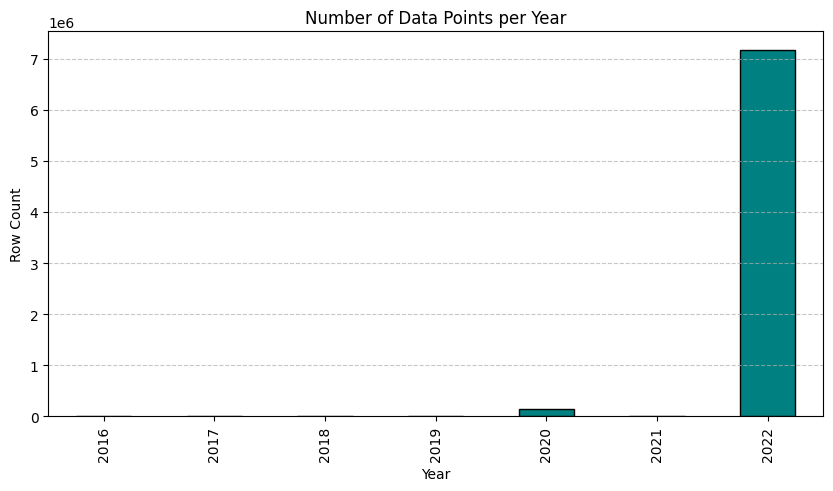

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure timestamp is datetime
df_split['timestamp'] = pd.to_datetime(df_split['timestamp'])

#  Calculate Rows Per Year
yearly_counts = df_split['timestamp'].dt.year.value_counts().sort_index()

#  Calculate Percentage
yearly_pct = (yearly_counts / len(df_split)) * 100

#  Display Table
print("\n=== DATA DISTRIBUTION BY YEAR ===")
print(f"{'Year':<6} | {'Rows':>12} | {'% of Total':>10}")
print("-" * 35)
for year, count in yearly_counts.items():
    pct = yearly_pct[year]
    print(f"{year:<6} | {count:12,} | {pct:9.1f}%")
print("-" * 35)

#  Quick Bar Chart (Visual Confirmation)
plt.figure(figsize=(10, 5))
yearly_counts.plot(kind='bar', color='teal', edgecolor='black')
plt.title('Number of Data Points per Year')
plt.xlabel('Year')
plt.ylabel('Row Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import pandas as pd

df_split['timestamp'] = pd.to_datetime(df_split['timestamp']).dt.tz_localize(None)

#  DEFINE THE CUTOFF (1 week future simulation)
cutoff_date = pd.Timestamp('2022-05-20')

print(f"Splitting data at: {cutoff_date}")

#  PERFORM THE TIME SPLIT
df_history = df_split[df_split['timestamp'] < cutoff_date].copy()
df_future  = df_split[df_split['timestamp'] >= cutoff_date].copy()

# VERIFY THE SPLIT
print("-" * 40)
print(f" SPLIT COMPLETE")
print(f"1. df_history (Train/Dev):   {len(df_history):,} rows")
print(f"   (Range: {df_history['timestamp'].min()} to {df_history['timestamp'].max()})")
print(f"2. df_future (Test/Sim):     {len(df_future):,} rows")
print(f"   (Range: {df_future['timestamp'].min()} to {df_future['timestamp'].max()})")
print("-" * 40)

# Check that we didn't lose any cities in the future set
print(f"Unique Cities in History: {df_history['station_name'].nunique()}")
print(f"Unique Cities in Future:  {df_future['station_name'].nunique()}")

Splitting data at: 2022-05-20 00:00:00
----------------------------------------
 SPLIT COMPLETE
1. df_history (Train/Dev):   6,563,757 rows
   (Range: 2016-02-09 20:00:00 to 2022-05-19 23:00:00)
2. df_future (Test/Sim):     808,449 rows
   (Range: 2022-05-20 00:00:00 to 2022-05-26 18:00:00)
----------------------------------------
Unique Cities in History: 8485
Unique Cities in Future:  5873


In [ ]:
df_history.head()

,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name,local_time,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,pollutant_fraction,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos
3533880,2016-02-09 20:00:00,GB,Haringey,Haringey - Haringey Town Hall,51.59,-0.11,10.00,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network,2016-02-09 19:59:35+00:00,19,2,1,0,1,3,0.17,10.00,NaN,NaN,NaN,NaN,NaN,-0.97,0.26
3533931,2016-02-09 20:00:00,GB,London,Haringey Roadside,51.51,-0.13,10.00,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 19:59:29+00:00,19,2,1,0,1,3,0.17,10.00,NaN,NaN,NaN,NaN,NaN,-0.97,0.26
3533932,2016-02-09 21:00:00,GB,London,Haringey Roadside,51.51,-0.13,10.00,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 20:59:29+00:00,20,2,1,0,1,3,0.17,10.00,NaN,NaN,NaN,NaN,NaN,-0.87,0.50
3533881,2016-02-09 21:00:00,GB,Haringey,Haringey - Haringey Town Hall,51.59,-0.11,10.00,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network,2016-02-09 20:59:35+00:00,20,2,1,0,1,3,0.17,10.00,NaN,NaN,NaN,NaN,NaN,-0.87,0.50
3533933,2016-02-09 22:00:00,GB,London,Haringey Roadside,51.51,-0.13,10.00,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 21:59:29+00:00,21,2,1,0,1,4,0.17,10.00,NaN,NaN,NaN,NaN,NaN,-0.71,0.71


In [ ]:
df_future.to_csv('Test_AQI.csv')

AQI CALCULATION

In [ ]:
import pandas as pd
import numpy as np
breakpoints = {
    'PM2.5 (µg/m³)': [
        (0.0,     12.0,   0, 50),
        (12.001,  35.4,  51, 100),
        (35.401,  55.4, 101, 150),
        (55.401, 150.4, 151, 200),
        (150.401, 250.4, 201, 300),43
        (250.401, 350.4, 301, 400),
        (350.401, 500.4, 401, 500)
    ],

    'PM10 (µg/m³)': [
        (0.0,     54.0,   0, 50),
        (54.001, 154.0,  51, 100),
        (154.001, 254.0, 101, 150),
        (254.001, 354.0, 151, 200),
        (354.001, 424.0, 201, 300),
        (424.001, 504.0, 301, 400),
        (504.001, 604.0, 401, 500)
    ],

    # NO2 (1-hour) -> Table 5 says 0-53 ppb, 54-100 ppb...
    # Factor: 1.88
    'NO2 (µg/m³)': [
        (0.0,      99.64,   0, 50),   # 53 * 1.88 = 99.64
        (99.641,   188.0,  51, 100),  # 100 * 1.88 = 188.0
        (188.001,  676.8, 101, 150),  # 360 * 1.88 = 676.8
        (676.801,  1220.1, 151, 200), # 649 * 1.88 = 1220.12
        (1220.101, 2348.1, 201, 300), # 1249 * 1.88 = 2348.12
        (2348.101, 3100.1, 301, 400), # 1649 * 1.88 = 3100.12
        (3100.101, 3852.1, 401, 500)  # 2049 * 1.88 = 3852.12
    ],

    # SO2 (1-hour) -> Table 5 says 0-35 ppb, 36-75 ppb...
    # Factor: 2.62
    'SO2 (µg/m³)': [
        (0.0,       91.7,   0, 50),   # 35 * 2.62 = 91.7
        (91.701,   196.5,  51, 100),  # 75 * 2.62 = 196.5
        (196.501,  484.7, 101, 150),  # 185 * 2.62 = 484.7
        (484.701,  796.5, 151, 200),  # 304 * 2.62 = 796.48
        (796.501, 1582.5, 201, 300),  # 604 * 2.62 = 1582.48
        (1582.501, 2106.5, 301, 400), # 804 * 2.62 = 2106.48
        (2106.501, 2630.5, 401, 500)  # 1004 * 2.62 = 2630.48
    ],

    # CO (8-hour) -
    # Factor: 1145 (since 1 ppm = 1.145 mg/m3 = 1145 ug/m3)
    'CO (µg/m³)': [
        (0.0,       5038.0,   0, 50),   # 4.4 * 1145 = 5038
        (5038.001, 10763.0,  51, 100),  # 9.4 * 1145 = 10763
        (10763.001, 14198.0, 101, 150), # 12.4 * 1145 = 14198
        (14198.001, 17633.0, 151, 200), # 15.4 * 1145 = 17633
        (17633.001, 34808.0, 201, 300), # 30.4 * 1145 = 34808
        (34808.001, 46258.0, 301, 400), # 40.4 * 1145 = 46258
        (46258.001, 57708.0, 401, 500)  # 50.4 * 1145 = 57708
    ],

    # Ozone (8-hour)
    # Factor: 1960 (since 1 ppm = 1000 ppb; 1000 * 1.96 = 1960)
    'O3 (µg/m³)': [
        (0.0,      105.8,   0, 50),   # 0.054 * 1960 = 105.84
        (105.801,  137.2,  51, 100),  # 0.070 * 1960 = 137.2
        (137.201,  166.6, 101, 150),  # 0.085 * 1960 = 166.6
        (166.601,  205.8, 151, 200),  # 0.105 * 1960 = 205.8
        (205.801,  392.0, 201, 300)   # 0.200 * 1960 = 392.0
    ]
}

# CALCULATE AQI SUB-INDICES
import numpy as np

def calculate_sub_index_fast(series, pollutant_name):
    """
    Super-fast Numpy implementation of AQI calc.
    5x-10x faster than Pandas .apply() or standard masking.
    """
    vals = series.to_numpy(dtype=float)

    # Pre-allocate result array with NaNs
    aqi_result = np.full(len(vals), np.nan)

    #  Get breakpoints
    bp_list = breakpoints.get(pollutant_name, [])

    # Loop through ranges using raw array masking
    for (low_c, high_c, low_i, high_i) in bp_list:
        # Create boolean mask
        mask = (vals >= low_c) & (vals <= high_c)

        # Only calculate if matches exist
        if np.any(mask):
            slope = (high_i - low_i) / (high_c - low_c)
            # Direct numpy array math
            aqi_result[mask] = slope * (vals[mask] - low_c) + low_i

    #  Handle "Beyond Index"
    if bp_list:
        max_c = bp_list[-1][1]
        mask_high = vals > max_c
        if np.any(mask_high):
            aqi_result[mask_high] = 500.0

    return aqi_result

# EXECUTION
print("1. Calculating Sub-Indices (Turbo Mode)...")
df_aqi = df_history.copy()
pollutant_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']
sub_index_cols = []

# Loop through columns and apply the fast function
for col in pollutant_cols:
    if col in df_aqi.columns:
        print(f"  -> Processing {col}...")
        si_col_name = f"{col.split(' ')[0]}_Idx"

        # CALL THE NEW FAST FUNCTION
        df_aqi[si_col_name] = calculate_sub_index_fast(df_aqi[col], col)

        sub_index_cols.append(si_col_name)

# Max Calculation
df_aqi['AQI_Value'] = df_aqi[sub_index_cols].max(axis=1)
print("Sub-Indices Calculated.")

#  CALCULATE CONFIDENCE SCORE
print("2. Assigning Weighted Confidence Scores...")

has_pm25 = df_aqi['PM2.5 (µg/m³)'].notna()
has_pm10 = df_aqi['PM10 (µg/m³)'].notna()
has_o3   = df_aqi['O3 (µg/m³)'].notna()
has_no2  = df_aqi['NO2 (µg/m³)'].notna()
has_so2  = df_aqi['SO2 (µg/m³)'].notna()
has_co   = df_aqi['CO (µg/m³)'].notna()

df_aqi['AQI_Confidence'] = 0

df_aqi.loc[has_pm25, 'AQI_Confidence'] = 75
df_aqi.loc[has_pm10 & ~has_pm25, 'AQI_Confidence'] = 60
df_aqi.loc[~has_pm10 & ~has_pm25, 'AQI_Confidence'] = 35


df_aqi.loc[has_pm10, 'AQI_Confidence'] += 10

df_aqi.loc[has_o3, 'AQI_Confidence'] += 5


minor_gas_count = (has_no2.astype(int) + has_so2.astype(int) + has_co.astype(int))
df_aqi['AQI_Confidence'] += (minor_gas_count * 4)

# Cleanup
df_aqi['AQI_Confidence'] = df_aqi['AQI_Confidence'].clip(upper=100)
df_aqi.loc[df_aqi['AQI_Value'].isna(), 'AQI_Confidence'] = 0

#  ASSIGN CATEGORIES
print("3. Assigning Categories...")
bins = [-1, 50, 100, 150, 200, 300, float('inf')]

# Define the corresponding labels
labels = [
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy',
    'Hazardous'
]

df_aqi['AQI_Category'] = pd.cut(df_aqi['AQI_Value'], bins=bins, labels=labels)

# Handle NaNs (if any AQI was NaN, fill with 'Unknown')
df_aqi['AQI_Category'] = df_aqi['AQI_Category'].cat.add_categories('Unknown').fillna('Unknown')

print(" Categories Assigned.")



1. Calculating Sub-Indices (Turbo Mode)...
  -> Processing PM2.5 (µg/m³)...
  -> Processing PM10 (µg/m³)...
  -> Processing NO2 (µg/m³)...
  -> Processing SO2 (µg/m³)...
  -> Processing O3 (µg/m³)...
  -> Processing CO (µg/m³)...
Sub-Indices Calculated.
2. Assigning Weighted Confidence Scores...
3. Assigning Categories...
 Categories Assigned.


In [ ]:
# Drop the intermediate sub-index columns if you don't want them
cols_to_drop = ['PM2.5_Idx', 'PM10_Idx', 'NO2_Idx', 'SO2_Idx', 'O3_Idx', 'CO_Idx','pollutant_fraction']
df_aqi.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(" Cleaned up sub-index columns.")

 Cleaned up sub-index columns.


In [ ]:
df_aqi.tail()

,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name,local_time,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos,AQI_Value,AQI_Confidence,AQI_Category
1278394,2022-05-19 23:00:00,GB,City of London,City of London - Beech Street,51.51,-0.13,NaN,16.00,29.55,NaN,NaN,NaN,2,London Air Quality Network,2022-05-19 22:59:29+00:00,22,5,3,0,2,4,NaN,17.47,49.37,NaN,NaN,NaN,-0.50,0.87,14.83,74,Good
5452823,2022-05-19 23:00:00,PT,Lisboa,PT03084,38.75,-9.23,NaN,29.46,14.13,NaN,69.93,NaN,3,EEA Portugal,2022-05-19 22:23:05+00:00,22,5,3,0,2,4,NaN,12.52,10.31,NaN,77.02,NaN,-0.50,0.87,33.05,79,Good
4304879,2022-05-19 23:00:00,US,Charleston-North Charleston,Jenkins Avenue,32.88,-79.98,NaN,23.67,4.39,0.00,NaN,NaN,3,AirNow,2022-05-19 17:40:05+00:00,17,5,3,0,2,3,NaN,19.91,5.05,0.27,NaN,NaN,-0.97,-0.26,21.91,78,Good
5179100,2022-05-19 23:00:00,IN,BDPO Office,"Nathu Colony, Ballabgarh - HSPCB",28.34,77.32,102.26,191.05,2.04,30.99,10.93,817.50,6,caaqm,2022-05-20 04:09:17+00:00,4,5,4,0,2,4,92.89,164.96,1.61,26.45,7.60,"1,145.94",0.87,0.50,175.17,100,Unhealthy
892577,2022-05-19 23:00:00,US,New York-Northern New Jersey-Long Island,CCNY,40.82,-73.95,8.57,NaN,NaN,NaN,49.00,NaN,2,AirNow,2022-05-19 18:04:12+00:00,18,5,3,0,2,3,4.48,NaN,NaN,NaN,50.91,NaN,-1.00,-0.00,35.69,80,Good


MINORITY SAMPLING USING GAN

In [ ]:
df_aqi['AQI_Category'].value_counts()

,count
AQI_Category,
Good,5264045
Moderate,963733
Unhealthy for Sensitive Groups,170558
Unhealthy,126576
Very Unhealthy,25611
Hazardous,13185
Unknown,49


In [ ]:
# Removing Unknown columns
df_aqi = df_aqi[df_aqi['AQI_Category'] != 'Unknown'].copy()
df_aqi['AQI_Category'].value_counts()

,count
AQI_Category,
Good,5264045
Moderate,963733
Unhealthy for Sensitive Groups,170558
Unhealthy,126576
Very Unhealthy,25611
Hazardous,13185
Unknown,0


In [ ]:
df_CTGAN = df_aqi.copy()

In [ ]:
df_CTGAN.columns

Index(['timestamp', 'country', 'region_name', 'station_name', 'latitude',
       'longitude', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
       'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)', 'pollutant_count',
       'source_name', 'local_time', 'local_hour', 'local_month',
       'local_day_of_week', 'is_weekend', 'season', 'time_of_day',
       'PM2.5_24h_mean', 'PM10_24h_mean', 'NO2_24h_mean', 'SO2_24h_mean',
       'O3_24h_mean', 'CO_24h_mean', 'hour_sin', 'hour_cos', 'AQI_Value',
       'AQI_Confidence', 'AQI_Category'],
      dtype='object')

In [ ]:
!pip install ctgan -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 29.0 MB/s eta 0:00:00


In [ ]:
# PREPARE THE DATA

# We define the categories we want to learn
target_classes = ['Very Unhealthy', 'Hazardous']

# Create a temporary subset from df_CTGAN
df_training_subset = df_CTGAN[
    (df_CTGAN['AQI_Category'].isin(target_classes))
].dropna()

#  CHECK DATA COUNT FOR MISSING DATA
original_dangerous_count = len(df_CTGAN[df_CTGAN['AQI_Category'].isin(target_classes)])
valid_training_rows = len(df_training_subset)

print(f"Original 'Very Unhealthy/Hazardous' rows in df_CTGAN: {original_dangerous_count}")
print(f"Rows with NO MISSING VALUES (Used for Training): {valid_training_rows}")


Original 'Very Unhealthy/Hazardous' rows in df_CTGAN: 38796
Rows with NO MISSING VALUES (Used for Training): 16403


In [ ]:
from ctgan import CTGAN

# DEFINE FEATURES (The Columns the GAN must learn)

# Continuous Columns
continuous_columns = [
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)', 'pollutant_count'
]

# Discrete Columns
discrete_columns = [
    'station_name', 'source_name',
    'local_hour', 'local_month', 'local_day_of_week',
    'is_weekend', 'season', 'time_of_day', 'AQI_Category'
]

# Combine them for the GAN
gan_features = continuous_columns + discrete_columns

print(f"\nTotal Features Selected: {len(gan_features)}")
print("Continuous:", continuous_columns)
print("Discrete:", discrete_columns)


Total Features Selected: 16
Continuous: ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)', 'pollutant_count']
Discrete: ['station_name', 'source_name', 'local_hour', 'local_month', 'local_day_of_week', 'is_weekend', 'season', 'time_of_day', 'AQI_Category']


In [ ]:
# Initialize the Model
ctgan = CTGAN(epochs=50, batch_size=500, verbose=True)

# START TRAINING
print("\n Starting CTGAN Training... ")
ctgan.fit(df_training_subset[gan_features], discrete_columns)

print("\n Training Complete!")


 Starting CTGAN Training... 


Gen. (-0.26) | Discrim. (-0.19): 100%|██████████| 50/50 [04:21<00:00,  5.22s/it]


 Training Complete!


In [ ]:
# GETTING THE ACTUAL DATA FROM TRAINED MODEL
import pandas as pd
import numpy as np
import random
import gc

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

# Batching
TARGET_CLEAN_ROWS = 150000
BATCH_SIZE = 50000
clean_data_list = []
total_collected = 0
cols_to_check = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)', 'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']

print(f">>> Starting generation. Target: {TARGET_CLEAN_ROWS} clean rows.")

# Loop
while total_collected < TARGET_CLEAN_ROWS:
    # Generate batch
    raw_batch = ctgan.sample(BATCH_SIZE)

    # Filter negatives
    condition = (raw_batch[cols_to_check] >= 0).all(axis=1)
    clean_batch = raw_batch[condition].copy()

    # Store good rows
    if not clean_batch.empty:
        clean_data_list.append(clean_batch)
        total_collected += len(clean_batch)
        print(f"   Collected {len(clean_batch)} clean rows. Total: {total_collected}")

    # Free memory
    del raw_batch
    del clean_batch
    gc.collect()

# Concatenate
synthetic_data = pd.concat(clean_data_list, ignore_index=True)
synthetic_data = synthetic_data.iloc[:TARGET_CLEAN_ROWS]  # Trim exact amount

print(f"\n>>> SUCCESS: Generated {len(synthetic_data)} clean rows.")
synthetic_data.head()

>>> Starting generation. Target: 150000 clean rows.
   Collected 38106 clean rows. Total: 38106
   Collected 37963 clean rows. Total: 76069
   Collected 37947 clean rows. Total: 114016
   Collected 38068 clean rows. Total: 152084

>>> SUCCESS: Generated 150000 clean rows.


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,station_name,source_name,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,AQI_Category
0,959.11,437.54,867.04,167.50,21.65,609.08,6,EE0018A,caaqm,15,6,5,1,2,4,Very Unhealthy
1,192.63,"1,083.75",28.50,43.23,11.56,"45,973.04",6,"Knowledge Park - III, Greater Noida - UPPCB",caaqm,21,2,5,1,2,1,Hazardous
2,96.74,612.36,8.03,21.08,104.85,899.31,6,"Suryakiran Bhawan NCL, Singrauli - MPPCB",caaqm,22,5,5,1,2,4,Very Unhealthy
3,340.73,482.91,24.70,24.34,30.34,"2,379.21",6,"Sanjay Nagar, Ghaziabad - UPPCB",caaqm,11,4,6,1,2,4,Hazardous
4,24.90,161.04,30.73,813.70,25.66,128.26,6,"Shastri Nagar, Narnaul - HSPCB",caaqm,6,4,0,0,2,3,Very Unhealthy


In [ ]:
# AUDIT: COUNT NEGATIVE VALUES
pollutant_cols = [
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)',
]

#  Count negatives per column
neg_counts = (synthetic_data[pollutant_cols] < 0).sum()

# Count total rows affected
rows_with_neg = (synthetic_data[pollutant_cols] < 0).any(axis=1).sum()
total_rows = len(synthetic_data)

print("--- NEGATIVE VALUE REPORT ---")
print(f"\nTotal Rows with at least one negative value: {rows_with_neg}")
print(f"Percentage of data affected: {(rows_with_neg/total_rows)*100:.2f}%")

--- NEGATIVE VALUE REPORT ---

Total Rows with at least one negative value: 0
Percentage of data affected: 0.00%


In [ ]:
synthetic_data.shape

(150000, 16)

FILLING REMAINING COLUMNS IN SYNTHETIC DATA

In [ ]:
# MAPPING LOCATION DETAILS (The "Lookup" Strategy)

station_reference = df_CTGAN[[
    'station_name', 'latitude', 'longitude', 'country', 'region_name'
]].drop_duplicates('station_name')

print(f">>> Created Reference Map with {len(station_reference)} unique stations.")

#  MERGE
synthetic_data = synthetic_data.merge(
    station_reference,
    on='station_name',
    how='left'
)

# VERIFY
print("\n>>> Mapping Complete. Checking first 5 rows:")
synthetic_data.head()


>>> Created Reference Map with 8485 unique stations.

>>> Mapping Complete. Checking first 5 rows:


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,station_name,source_name,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,AQI_Category,latitude,longitude,country,region_name
0,959.11,437.54,867.04,167.50,21.65,609.08,6,EE0018A,caaqm,15,6,5,1,2,4,Very Unhealthy,59.41,24.65,EE,Harjumaa
1,192.63,"1,083.75",28.50,43.23,11.56,"45,973.04",6,"Knowledge Park - III, Greater Noida - UPPCB",caaqm,21,2,5,1,2,1,Hazardous,28.47,77.51,IN,Greater Noida
2,96.74,612.36,8.03,21.08,104.85,899.31,6,"Suryakiran Bhawan NCL, Singrauli - MPPCB",caaqm,22,5,5,1,2,4,Very Unhealthy,24.24,82.38,IN,Singrauli
3,340.73,482.91,24.70,24.34,30.34,"2,379.21",6,"Sanjay Nagar, Ghaziabad - UPPCB",caaqm,11,4,6,1,2,4,Hazardous,28.69,77.45,IN,Ghaziabad
4,24.90,161.04,30.73,813.70,25.66,128.26,6,"Shastri Nagar, Narnaul - HSPCB",caaqm,6,4,0,0,2,3,Very Unhealthy,28.06,76.11,IN,Mini Secretariat


In [ ]:
# GENERATING DATES
print(">>> Building Historical Calendar (2018 to May 2022)...")

#  DEFINE THE STRICT CUTOFF
test_start_date = pd.Timestamp('2022-05-20')

#  GENERATE VALID DATES
valid_dates_df = pd.DataFrame({
    'date': pd.date_range(start='2018-01-01', end=test_start_date - pd.Timedelta(days=1), freq='D')
})

print(f"   Calendar Start: {valid_dates_df['date'].min().date()}")
print(f"   Calendar End:   {valid_dates_df['date'].max().date()}")
print(f"   Total Valid Days: {len(valid_dates_df)}")

#  BUILD LOOKUP DICTIONARY
valid_dates_df['month'] = valid_dates_df['date'].dt.month
valid_dates_df['day_of_week'] = valid_dates_df['date'].dt.dayofweek

date_lookup = valid_dates_df.groupby(['month', 'day_of_week'])['date'].apply(list).to_dict()

# ASSIGN DATES
def get_historical_date(row):
    m = row['local_month']
    d = row['local_day_of_week']

    # Get valid historical dates for this Month & Weekday
    valid_options = date_lookup.get((m, d))

    # Pick one randomly
    if valid_options:
        return np.random.choice(valid_options)

    # Fallback (Safety): Return a safe date in 2019
    return pd.Timestamp("2019-01-01")

print(">>> Assigning dates...")
synthetic_data['temp_date'] = synthetic_data.apply(get_historical_date, axis=1)

# CONSTRUCT FINAL TIMESTAMPS
# Local Time = Date + Hour
synthetic_data['local_time'] = synthetic_data['temp_date'] + pd.to_timedelta(synthetic_data['local_hour'], unit='h')

# UTC Timestamp = Local - (Longitude offset)
synthetic_data['utc_offset'] = pd.to_timedelta(synthetic_data['longitude'] / 15, unit='h')
synthetic_data['timestamp'] = (synthetic_data['local_time'] - synthetic_data['utc_offset']).dt.round('s')

# Cycles
synthetic_data['hour_sin'] = np.sin(2 * np.pi * synthetic_data['local_hour'] / 24).astype(np.float32)
synthetic_data['hour_cos'] = np.cos(2 * np.pi * synthetic_data['local_hour'] / 24).astype(np.float32)

# Cleanup
synthetic_data.drop(columns=['temp_date', 'utc_offset'], inplace=True)

synthetic_data.head()

>>> Building Historical Calendar (2018 to May 2022)...
   Calendar Start: 2018-01-01
   Calendar End:   2022-05-19
   Total Valid Days: 1600
>>> Assigning dates...


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,station_name,source_name,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,AQI_Category,latitude,longitude,country,region_name,local_time,timestamp,hour_sin,hour_cos
0,959.11,437.54,867.04,167.50,21.65,609.08,6,EE0018A,caaqm,15,6,5,1,2,4,Very Unhealthy,59.41,24.65,EE,Harjumaa,2020-06-13 15:00:00,2020-06-13 13:21:24,-0.71,-0.71
1,192.63,"1,083.75",28.50,43.23,11.56,"45,973.04",6,"Knowledge Park - III, Greater Noida - UPPCB",caaqm,21,2,5,1,2,1,Hazardous,28.47,77.51,IN,Greater Noida,2018-02-17 21:00:00,2018-02-17 15:49:57,-0.71,0.71
2,96.74,612.36,8.03,21.08,104.85,899.31,6,"Suryakiran Bhawan NCL, Singrauli - MPPCB",caaqm,22,5,5,1,2,4,Very Unhealthy,24.24,82.38,IN,Singrauli,2020-05-16 22:00:00,2020-05-16 16:30:28,-0.50,0.87
3,340.73,482.91,24.70,24.34,30.34,"2,379.21",6,"Sanjay Nagar, Ghaziabad - UPPCB",caaqm,11,4,6,1,2,4,Hazardous,28.69,77.45,IN,Ghaziabad,2019-04-21 11:00:00,2019-04-21 05:50:11,0.26,-0.97
4,24.90,161.04,30.73,813.70,25.66,128.26,6,"Shastri Nagar, Narnaul - HSPCB",caaqm,6,4,0,0,2,3,Very Unhealthy,28.06,76.11,IN,Mini Secretariat,2019-04-29 06:00:00,2019-04-29 00:55:33,1.00,0.00


In [ ]:
# CREATING 24_H MEAN COLUMNS
synthetic_data = synthetic_data.sort_values(['station_name', 'timestamp'])

pollutant_cols = [
    'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)'
]

# APPLY THE ROLLING CALCULATION LOOP
for col in pollutant_cols:
    if col in synthetic_data.columns:
        # Create the new column name
        short_name = col.split(' ')[0]
        target_col = f'{short_name}_24h_mean'

        print(f"   Processing {target_col}...")

        # Calculate Rolling Mean
        rolling_series = (
            synthetic_data.groupby('station_name')[col]
            .rolling(24, min_periods=1)
            .mean()
            .reset_index(level=0, drop=True)
        )

        # Assign strictly by index to keep data aligned
        synthetic_data[target_col] = rolling_series.astype(np.float32)

synthetic_data.head()

   Processing PM2.5_24h_mean...
   Processing PM10_24h_mean...
   Processing NO2_24h_mean...
   Processing SO2_24h_mean...
   Processing O3_24h_mean...
   Processing CO_24h_mean...


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,station_name,source_name,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,AQI_Category,latitude,longitude,country,region_name,local_time,timestamp,hour_sin,hour_cos,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean
17280,216.26,429.99,27.66,9.63,54.54,"2,293.76",6,"Olsztyn, ul. Puszkina",caaqm,15,4,4,0,2,4,Hazardous,53.78,20.48,PL,Olsztyn,2018-04-13 15:00:00,2018-04-13 13:38:06,-0.71,-0.71,216.26,429.99,27.66,9.63,54.54,"2,293.76"
103765,159.49,135.01,64.31,21.76,54.99,"4,096.82",6,"Olsztyn, ul. Puszkina",caaqm,20,4,5,1,2,3,Hazardous,53.78,20.48,PL,Olsztyn,2018-04-14 20:00:00,2018-04-14 18:38:06,-0.87,0.50,187.87,282.50,45.98,15.70,54.76,"3,195.29"
117848,145.80,102.56,190.60,7.70,103.87,"1,303.59",6,"Olsztyn, ul. Puszkina",caaqm,23,4,5,0,2,3,Very Unhealthy,53.78,20.48,PL,Olsztyn,2018-04-14 23:00:00,2018-04-14 21:38:06,-0.26,0.97,173.85,222.52,94.19,13.03,71.13,"2,564.73"
89737,162.43,30.05,24.04,16.94,51.74,"2,731.87",6,"Olsztyn, ul. Puszkina",caaqm,7,4,1,0,2,4,Hazardous,53.78,20.48,PL,Olsztyn,2018-04-17 07:00:00,2018-04-17 05:38:06,0.97,-0.26,170.99,174.40,76.65,14.01,66.28,"2,606.51"
93985,184.10,465.10,49.94,50.76,91.07,"1,730.48",6,"Olsztyn, ul. Puszkina",caaqm,14,4,3,0,2,4,Very Unhealthy,53.78,20.48,PL,Olsztyn,2018-04-19 14:00:00,2018-04-19 12:38:06,-0.50,-0.87,173.61,232.54,71.31,21.36,71.24,"2,431.31"


In [ ]:
# AQI Values
breakpoints = {
    'PM2.5 (µg/m³)': [
        (0.0,     12.0,   0, 50),
        (12.001,  35.4,  51, 100),
        (35.401,  55.4, 101, 150),
        (55.401, 150.4, 151, 200),
        (150.401, 250.4, 201, 300),
        (250.401, 350.4, 301, 400),
        (350.401, 500.4, 401, 500)
    ],

    'PM10 (µg/m³)': [
        (0.0,     54.0,   0, 50),
        (54.001, 154.0,  51, 100),
        (154.001, 254.0, 101, 150),
        (254.001, 354.0, 151, 200),
        (354.001, 424.0, 201, 300),
        (424.001, 504.0, 301, 400),
        (504.001, 604.0, 401, 500)
    ],

    # NO2 (1-hour) -> Table 5 says 0-53 ppb, 54-100 ppb...
    # Factor: 1.88
    'NO2 (µg/m³)': [
        (0.0,      99.64,   0, 50),   # 53 * 1.88 = 99.64
        (99.641,   188.0,  51, 100),  # 100 * 1.88 = 188.0
        (188.001,  676.8, 101, 150),  # 360 * 1.88 = 676.8
        (676.801,  1220.1, 151, 200), # 649 * 1.88 = 1220.12
        (1220.101, 2348.1, 201, 300), # 1249 * 1.88 = 2348.12
        (2348.101, 3100.1, 301, 400), # 1649 * 1.88 = 3100.12
        (3100.101, 3852.1, 401, 500)  # 2049 * 1.88 = 3852.12
    ],

    # SO2 (1-hour) -> Table 5 says 0-35 ppb, 36-75 ppb...
    # Factor: 2.62
    'SO2 (µg/m³)': [
        (0.0,       91.7,   0, 50),   # 35 * 2.62 = 91.7
        (91.701,   196.5,  51, 100),  # 75 * 2.62 = 196.5
        (196.501,  484.7, 101, 150),  # 185 * 2.62 = 484.7
        (484.701,  796.5, 151, 200),  # 304 * 2.62 = 796.48
        (796.501, 1582.5, 201, 300),  # 604 * 2.62 = 1582.48
        (1582.501, 2106.5, 301, 400), # 804 * 2.62 = 2106.48
        (2106.501, 2630.5, 401, 500)  # 1004 * 2.62 = 2630.48
    ],

    # CO (8-hour) -
    # Factor: 1145 (since 1 ppm = 1.145 mg/m3 = 1145 ug/m3)
    'CO (µg/m³)': [
        (0.0,       5038.0,   0, 50),   # 4.4 * 1145 = 5038
        (5038.001, 10763.0,  51, 100),  # 9.4 * 1145 = 10763
        (10763.001, 14198.0, 101, 150), # 12.4 * 1145 = 14198
        (14198.001, 17633.0, 151, 200), # 15.4 * 1145 = 17633
        (17633.001, 34808.0, 201, 300), # 30.4 * 1145 = 34808
        (34808.001, 46258.0, 301, 400), # 40.4 * 1145 = 46258
        (46258.001, 57708.0, 401, 500)  # 50.4 * 1145 = 57708
    ],

    # Ozone (8-hour)
    # Factor: 1960 (since 1 ppm = 1000 ppb; 1000 * 1.96 = 1960)
    'O3 (µg/m³)': [
        (0.0,      105.8,   0, 50),   # 0.054 * 1960 = 105.84
        (105.801,  137.2,  51, 100),  # 0.070 * 1960 = 137.2
        (137.201,  166.6, 101, 150),  # 0.085 * 1960 = 166.6
        (166.601,  205.8, 151, 200),  # 0.105 * 1960 = 205.8
        (205.801,  392.0, 201, 300)   # 0.200 * 1960 = 392.0
    ]
}

# FAST CALCULATOR
def calculate_sub_index_fast(series, pollutant_name):
    vals = series.to_numpy(dtype=float)
    aqi_result = np.full(len(vals), np.nan)

    # Get breakpoints
    bp_list = breakpoints.get(pollutant_name, [])

    # Loop through ranges
    for (low_c, high_c, low_i, high_i) in bp_list:
        mask = (vals >= low_c) & (vals <= high_c)
        if np.any(mask):
            slope = (high_i - low_i) / (high_c - low_c) if (high_c - low_c) != 0 else 0
            aqi_result[mask] = slope * (vals[mask] - low_c) + low_i

    # Handle "Beyond Index"
    if bp_list:
        max_c = bp_list[-1][1]
        mask_high = vals > max_c
        if np.any(mask_high):
            aqi_result[mask_high] = 500.0

    return aqi_result

# EXECUTE CALCULATION
print(">>> Calculating AQI Sub-Indices (Using Raw 1-hour Values)...")

sub_index_cols = []
pollutant_cols = ['PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
                  'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)']

for col in pollutant_cols:
    if col in synthetic_data.columns:
        print(f"   Processing {col}...")
        si_name = f"{col.split(' ')[0]}_Idx"

        # Calculate using RAW values
        synthetic_data[si_name] = calculate_sub_index_fast(synthetic_data[col], col)
        sub_index_cols.append(si_name)

# FINAL COLUMNS
# Max Sub-Index becomes AQI Value
synthetic_data['AQI_Value'] = synthetic_data[sub_index_cols].max(axis=1).fillna(0).astype(int)

# Set Confidence to 101 (for pseudo data)
synthetic_data['AQI_Confidence'] = 101

#  ASSIGN CATEGORIES
print("3. Assigning Categories...")
bins = [-1, 50, 100, 150, 200, 300, float('inf')]

# Define the corresponding labels
labels = [
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy',
    'Hazardous'
]

synthetic_data['AQI_Category'] = pd.cut(synthetic_data['AQI_Value'], bins=bins, labels=labels)

synthetic_data.head()

>>> Calculating AQI Sub-Indices (Using Raw 1-hour Values)...
   Processing PM2.5 (µg/m³)...
   Processing PM10 (µg/m³)...
   Processing NO2 (µg/m³)...
   Processing SO2 (µg/m³)...
   Processing O3 (µg/m³)...
   Processing CO (µg/m³)...
3. Assigning Categories...


,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,station_name,source_name,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,AQI_Category,latitude,longitude,country,region_name,local_time,timestamp,hour_sin,hour_cos,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,PM2.5_Idx,PM10_Idx,NO2_Idx,SO2_Idx,O3_Idx,CO_Idx,AQI_Value,AQI_Confidence
17280,216.26,429.99,27.66,9.63,54.54,"2,293.76",6,"Olsztyn, ul. Puszkina",caaqm,15,4,4,0,2,4,Hazardous,53.78,20.48,PL,Olsztyn,2018-04-13 15:00:00,2018-04-13 13:38:06,-0.71,-0.71,216.26,429.99,27.66,9.63,54.54,"2,293.76",266.20,308.42,13.88,5.25,25.78,22.76,308,101
103765,159.49,135.01,64.31,21.76,54.99,"4,096.82",6,"Olsztyn, ul. Puszkina",caaqm,20,4,5,1,2,3,Very Unhealthy,53.78,20.48,PL,Olsztyn,2018-04-14 20:00:00,2018-04-14 18:38:06,-0.87,0.50,187.87,282.50,45.98,15.70,54.76,"3,195.29",209.99,90.70,32.27,11.86,25.99,40.66,209,101
117848,145.80,102.56,190.60,7.70,103.87,"1,303.59",6,"Olsztyn, ul. Puszkina",caaqm,23,4,5,0,2,3,Unhealthy,53.78,20.48,PL,Olsztyn,2018-04-14 23:00:00,2018-04-14 21:38:06,-0.26,0.97,173.85,222.52,94.19,13.03,71.13,"2,564.73",197.63,74.79,101.26,4.20,49.09,12.94,197,101
89737,162.43,30.05,24.04,16.94,51.74,"2,731.87",6,"Olsztyn, ul. Puszkina",caaqm,7,4,1,0,2,4,Very Unhealthy,53.78,20.48,PL,Olsztyn,2018-04-17 07:00:00,2018-04-17 05:38:06,0.97,-0.26,170.99,174.40,76.65,14.01,66.28,"2,606.51",212.91,27.82,12.06,9.24,24.45,27.11,212,101
93985,184.10,465.10,49.94,50.76,91.07,"1,730.48",6,"Olsztyn, ul. Puszkina",caaqm,14,4,3,0,2,4,Hazardous,53.78,20.48,PL,Olsztyn,2018-04-19 14:00:00,2018-04-19 12:38:06,-0.50,-0.87,173.61,232.54,71.31,21.36,71.24,"2,431.31",234.36,351.86,25.06,27.68,43.04,17.17,351,101


In [ ]:
# Define the exact column order
desired_order = [
    'timestamp', 'country', 'region_name', 'station_name', 'latitude',
    'longitude', 'PM2.5 (µg/m³)', 'PM10 (µg/m³)', 'NO2 (µg/m³)',
    'SO2 (µg/m³)', 'O3 (µg/m³)', 'CO (µg/m³)', 'pollutant_count',
    'source_name', 'local_time', 'local_hour', 'local_month',
    'local_day_of_week', 'is_weekend', 'season', 'time_of_day',
    'PM2.5_24h_mean', 'PM10_24h_mean', 'NO2_24h_mean', 'SO2_24h_mean',
    'O3_24h_mean', 'CO_24h_mean', 'hour_sin', 'hour_cos', 'AQI_Value',
    'AQI_Confidence', 'AQI_Category'
]

# Apply the order
synthetic_data = synthetic_data[desired_order]
synthetic_data.head()

,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name,local_time,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos,AQI_Value,AQI_Confidence,AQI_Category
17280,2018-04-13 13:38:06,PL,Olsztyn,"Olsztyn, ul. Puszkina",53.78,20.48,216.26,429.99,27.66,9.63,54.54,"2,293.76",6,caaqm,2018-04-13 15:00:00,15,4,4,0,2,4,216.26,429.99,27.66,9.63,54.54,"2,293.76",-0.71,-0.71,308,101,Hazardous
103765,2018-04-14 18:38:06,PL,Olsztyn,"Olsztyn, ul. Puszkina",53.78,20.48,159.49,135.01,64.31,21.76,54.99,"4,096.82",6,caaqm,2018-04-14 20:00:00,20,4,5,1,2,3,187.87,282.50,45.98,15.70,54.76,"3,195.29",-0.87,0.50,209,101,Very Unhealthy
117848,2018-04-14 21:38:06,PL,Olsztyn,"Olsztyn, ul. Puszkina",53.78,20.48,145.80,102.56,190.60,7.70,103.87,"1,303.59",6,caaqm,2018-04-14 23:00:00,23,4,5,0,2,3,173.85,222.52,94.19,13.03,71.13,"2,564.73",-0.26,0.97,197,101,Unhealthy
89737,2018-04-17 05:38:06,PL,Olsztyn,"Olsztyn, ul. Puszkina",53.78,20.48,162.43,30.05,24.04,16.94,51.74,"2,731.87",6,caaqm,2018-04-17 07:00:00,7,4,1,0,2,4,170.99,174.40,76.65,14.01,66.28,"2,606.51",0.97,-0.26,212,101,Very Unhealthy
93985,2018-04-19 12:38:06,PL,Olsztyn,"Olsztyn, ul. Puszkina",53.78,20.48,184.10,465.10,49.94,50.76,91.07,"1,730.48",6,caaqm,2018-04-19 14:00:00,14,4,3,0,2,4,173.61,232.54,71.31,21.36,71.24,"2,431.31",-0.50,-0.87,351,101,Hazardous


MERGING SYNTHETIC DATA AND ORIGINAL DATA

In [ ]:
gc.collect()
print(f"Original Row Count: {len(df_CTGAN)}")
print(f"Synthetic Row Count: {len(synthetic_data)}")

#  Concatenate the dataframe
df_CTGAN = pd.concat([df_CTGAN, synthetic_data], axis=0, ignore_index=True)

df_CTGAN.head()

Original Row Count: 6563708
Synthetic Row Count: 150000


,timestamp,country,region_name,station_name,latitude,longitude,PM2.5 (µg/m³),PM10 (µg/m³),NO2 (µg/m³),SO2 (µg/m³),O3 (µg/m³),CO (µg/m³),pollutant_count,source_name,local_time,local_hour,local_month,local_day_of_week,is_weekend,season,time_of_day,PM2.5_24h_mean,PM10_24h_mean,NO2_24h_mean,SO2_24h_mean,O3_24h_mean,CO_24h_mean,hour_sin,hour_cos,AQI_Value,AQI_Confidence,AQI_Category
0,2016-02-09 20:00:00,GB,Haringey,Haringey - Haringey Town Hall,51.59,-0.11,10.00,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network,2016-02-09 19:59:35+00:00,19,2,1,0,1,3,10.00,NaN,NaN,NaN,NaN,NaN,-0.97,0.26,41.67,75,Good
1,2016-02-09 20:00:00,GB,London,Haringey Roadside,51.51,-0.13,10.00,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 19:59:29+00:00,19,2,1,0,1,3,10.00,NaN,NaN,NaN,NaN,NaN,-0.97,0.26,41.67,75,Good
2,2016-02-09 21:00:00,GB,London,Haringey Roadside,51.51,-0.13,10.00,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 20:59:29+00:00,20,2,1,0,1,3,10.00,NaN,NaN,NaN,NaN,NaN,-0.87,0.50,41.67,75,Good
3,2016-02-09 21:00:00,GB,Haringey,Haringey - Haringey Town Hall,51.59,-0.11,10.00,NaN,NaN,NaN,NaN,NaN,1,London Air Quality Network,2016-02-09 20:59:35+00:00,20,2,1,0,1,3,10.00,NaN,NaN,NaN,NaN,NaN,-0.87,0.50,41.67,75,Good
4,2016-02-09 22:00:00,GB,London,Haringey Roadside,51.51,-0.13,10.00,NaN,NaN,NaN,NaN,NaN,1,DEFRA,2016-02-09 21:59:29+00:00,21,2,1,0,1,4,10.00,NaN,NaN,NaN,NaN,NaN,-0.71,0.71,41.67,75,Good


In [ ]:
# 1. Define the correct order
aqi_order = [
    'Good',
    'Moderate',
    'Unhealthy for Sensitive Groups',
    'Unhealthy',
    'Very Unhealthy',
    'Hazardous'
]

# 2. Convert to Ordered Category
df_CTGAN['AQI_Category'] = pd.Categorical(
    df_CTGAN['AQI_Category'],
    categories=aqi_order,
    ordered=True
)


In [ ]:
df_CTGAN['AQI_Category'].value_counts()

,count
AQI_Category,
Good,5265304
Moderate,968312
Unhealthy for Sensitive Groups,172964
Unhealthy,141184
Hazardous,84146
Very Unhealthy,81798


In [ ]:
df_CTGAN.dtypes

,0
timestamp,datetime64[ns]
country,object
region_name,object
station_name,object
latitude,float32
longitude,float32
PM2.5 (µg/m³),float32
PM10 (µg/m³),float32
NO2 (µg/m³),float32
SO2 (µg/m³),float32


In [ ]:
# df_CTGAN.to_csv('AQI_Minority_Sampled_GAN.csv')